# SEL — 4 Experiment Benchmark
1. **Baseline CNN** — standard ResNet-18, full data, 30 epochs
2. **Lottery Ticket** — prune then retrain
3. **SEL 95%** — staged embarrassment, target 95% sparsity for better accuracy
4. **Warmup+SEL** — first 20% samples baseline warmup, then staged embarrassment

Test set: 100 held-out images per class (1000 total, never seen during training)

**Runtime → T4 GPU**

In [ ]:
# CELL 1 — Imports and Config
import torch, time, warnings, random, copy
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42); np.random.seed(42); random.seed(42)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
N_CLASSES   = 10
BATCH_SIZE  = 64
BASE_LR     = 1e-3
BASELINE_EPOCHS = 30
TOTAL_PARAMS    = None

# SEL 95% config — guilt at p40 (60% gradients pass) for better accuracy
STAGE_CONFIG = [
    ('Stage 1 Easy',    0.00, 0.25, 0.30, 10),
    ('Stage 2 Medium',  0.20, 0.50, 0.45, 10),
    ('Stage 3 Hard',    0.40, 0.65, 0.58, 10),
    ('Stage 4 Harder',  0.60, 0.82, 0.68, 10),
    ('Stage 5 Hardest', 0.78, 1.00, 0.76, 10),
]
SAMPLES_PER_CLASS = 2000
TEMPERATURE       = 1.5
STAGED_EPOCHS     = sum(s[4] for s in STAGE_CONFIG)

# Lottery ticket config
LT_PRUNE_PCT  = 0.80   # prune 80% of weights
LT_EPOCHS     = 30

# Warmup+SEL: first 20% of training data as baseline warmup
WARMUP_EPOCHS = 5

print(f'Baseline epochs : {BASELINE_EPOCHS}')
print(f'Staged epochs   : {STAGED_EPOCHS}')
print(f'LT prune pct    : {LT_PRUNE_PCT:.0%}')
print(f'Warmup epochs   : {WARMUP_EPOCHS}')

Device: cuda
GPU: Tesla T4
Baseline epochs : 30
Staged epochs   : 50
LT prune pct    : 80%
Warmup epochs   : 5


In [ ]:
# CELL 2 — Dataset + Held-out Test Set
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.4914,0.4822,0.4465],[0.2470,0.2435,0.2616])
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914,0.4822,0.4465],[0.2470,0.2435,0.2616])
])

full_train   = datasets.CIFAR10('/content/data', train=True,  download=True, transform=train_tf)
full_test    = datasets.CIFAR10('/content/data', train=False, download=True, transform=test_tf)
base_loader  = DataLoader(full_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
full_test_loader = DataLoader(full_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Held-out: 100 per class = 1000 images never seen during training
test_100_idx = []
for c in range(N_CLASSES):
    idx = [i for i,(_, l) in enumerate(full_test) if l == c][:100]
    test_100_idx.extend(idx)
test_100_loader = DataLoader(Subset(full_test, test_100_idx),
                              batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Train        : {len(full_train)}')
print(f'Full test    : {len(full_test)}')
print(f'Held-out test: 1000 (100 per class)')

100%|██████████| 170M/170M [00:07<00:00, 24.3MB/s]


Train        : 50000
Full test    : 10000
Held-out test: 1000 (100 per class)


In [ ]:
# CELL 3 — Model, FLOPs, Eval Functions
def build_model():
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    m.maxpool = nn.Identity()
    m.fc      = nn.Linear(512, N_CLASSES)
    return m.to(DEVICE)

tmp = build_model()
TOTAL_PARAMS = sum(p.numel() for p in tmp.parameters())
del tmp

def count_flops(sp, n): return 2 * TOTAL_PARAMS * (1.0 - sp) * n

def eval_full(model):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for imgs, labels in full_test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            correct += (model(imgs).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total

def eval_100(model):
    model.eval()
    cc, ct = [0]*N_CLASSES, [0]*N_CLASSES
    with torch.no_grad():
        for imgs, labels in test_100_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs).argmax(1)
            for i in range(len(labels)):
                l = labels[i].item()
                cc[l] += (preds[i] == labels[i]).item()
                ct[l] += 1
    pc  = np.array([cc[i]/max(ct[i],1) for i in range(N_CLASSES)])
    avg = sum(cc)/sum(ct)
    return pc, avg

print(f'ResNet-18 params : {TOTAL_PARAMS:,}')
print(f'Dense FLOPs/epoch: {2*TOTAL_PARAMS*50000/1e12:.3f}T')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


ResNet-18 params : 11,173,962
Dense FLOPs/epoch: 1.117T


In [ ]:
# CELL 4 — Per-Class Sorted Pools + Guilt Threshold
print('Sorting training data per class...')
scorer = build_model(); scorer.eval()
crit_r = nn.CrossEntropyLoss(reduction='none')
all_loss, all_lbl = [], []
with torch.no_grad():
    for imgs, labels in DataLoader(full_train, batch_size=256, shuffle=False, num_workers=2):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        all_loss.extend(crit_r(scorer(imgs), labels).cpu().numpy())
        all_lbl.extend(labels.cpu().numpy())
del scorer
all_loss = np.array(all_loss); all_lbl = np.array(all_lbl)

class_pools = {}
for c in range(N_CLASSES):
    idx   = np.where(all_lbl == c)[0]
    order = np.argsort(all_loss[idx])
    class_pools[c] = idx[order].tolist()
    print(f'  {CLASS_NAMES[c]:<12}: easy={all_loss[idx[order[0]]]:.3f}  hard={all_loss[idx[order[-1]]]:.3f}')

# p40 guilt threshold — 60% of gradients pass = better accuracy
tmp_m = build_model(); tmp_o = optim.Adam(tmp_m.parameters(), lr=BASE_LR)
ig, il = next(iter(DataLoader(full_train, batch_size=128)))
tmp_o.zero_grad()
nn.CrossEntropyLoss()(tmp_m(ig.to(DEVICE)), il.to(DEVICE)).backward()
grads = np.concatenate([p.grad.abs().cpu().numpy().flatten()
                        for p in tmp_m.parameters() if p.grad is not None])
GUILT_40 = float(np.percentile(grads, 40))   # SEL-95: p40 -> ~95% sparsity
del tmp_m
print(f'\nGuilt p40 (SEL-95): {GUILT_40:.6f}')

def get_stage_loader(si):
    _, ps, pe, _, _ = STAGE_CONFIG[si]
    idx = []
    for c in range(N_CLASSES):
        pool = class_pools[c]
        s = int(ps*len(pool)); e = min(int(pe*len(pool)), s+SAMPLES_PER_CLASS)
        idx += pool[s:e]
    random.shuffle(idx)
    return DataLoader(Subset(full_train, idx), batch_size=BATCH_SIZE,
                      shuffle=True, num_workers=2)

# Warmup loader: first 20% easiest samples across all classes
warmup_idx = []
for c in range(N_CLASSES):
    warmup_idx += class_pools[c][:1000]  # 1000 easiest per class
warmup_loader = DataLoader(Subset(full_train, warmup_idx),
                            batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f'Warmup loader: {len(warmup_idx)} samples')

Sorting training data per class...
  airplane    : easy=0.747  hard=3.604
  automobile  : easy=0.892  hard=3.373
  bird        : easy=1.301  hard=3.881
  cat         : easy=1.123  hard=3.556
  deer        : easy=0.989  hard=3.112
  dog         : easy=1.692  hard=3.851
  frog        : easy=1.424  hard=3.812
  horse       : easy=2.028  hard=5.623
  ship        : easy=1.542  hard=4.321
  truck       : easy=1.199  hard=3.678

Guilt p40 (SEL-95): 0.000604
Warmup loader: 10000 samples


In [ ]:
# CELL 5 — SEL Math Functions
def pc_embarrassment(logits, labels, T=TEMPERATURE):
    losses = nn.CrossEntropyLoss(reduction='none')(logits/T, labels)
    E, C = np.zeros(N_CLASSES), np.zeros(N_CLASSES)
    for c in range(N_CLASSES):
        m = (labels == c)
        if m.sum() > 0:
            e = losses[m].mean().item()
            E[c] = e; C[c] = max(0.0, 1.0 - e)
    return E, C

def sparse_update(model, gamma):
    tot = guilty = 0
    for p in model.parameters():
        if p.grad is not None:
            mask = (p.grad.abs() > gamma).float()
            p.grad.mul_(mask)
            tot += mask.numel(); guilty += mask.sum().item()
    return 1.0 - (guilty / max(tot, 1))

def run_sel_epoch(model, loader, opt, gamma):
    model.train()
    crit = nn.CrossEntropyLoss()
    E_sum = np.zeros(N_CLASSES); C_sum = np.zeros(N_CLASSES)
    sp_sum = nb = ls = cor = tot = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        opt.zero_grad()
        out  = model(imgs)
        loss = crit(out, labels)
        E_b, C_b = pc_embarrassment(out.detach(), labels)
        E_sum += E_b; C_sum += C_b
        for pg in opt.param_groups:
            pg['lr'] = BASE_LR * (1.0 + 2.0 * loss.item())
        loss.backward()
        sp = sparse_update(model, gamma)
        opt.step()
        ls  += loss.item() * labels.size(0)
        cor += (out.argmax(1) == labels).sum().item()
        tot += labels.size(0)
        sp_sum += sp; nb += 1
    return ls/tot, cor/tot, sp_sum/nb, E_sum/nb, C_sum/nb

def run_dense_epoch(model, loader, opt):
    model.train()
    crit = nn.CrossEntropyLoss()
    ls = cor = tot = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        opt.zero_grad()
        out  = model(imgs)
        loss = crit(out, labels)
        loss.backward(); opt.step()
        ls  += loss.item() * labels.size(0)
        cor += (out.argmax(1) == labels).sum().item()
        tot += labels.size(0)
    return ls/tot, cor/tot

print('SEL functions ready')

SEL functions ready


In [ ]:
# CELL 6 — Experiment 1: Baseline CNN
print('='*55); print('  EXP 1 — BASELINE CNN'); print('='*55)
e1_model = build_model()
e1_opt   = optim.Adam(e1_model.parameters(), lr=BASE_LR)
e1_hist  = []; e1_flops = 0.0
torch.cuda.reset_peak_memory_stats()
e1_t0 = time.time()

for ep in range(BASELINE_EPOCHS):
    tl, ta = run_dense_epoch(e1_model, base_loader, e1_opt)
    e1_flops += 2 * TOTAL_PARAMS * len(full_train)
    fa = eval_full(e1_model)
    pc, t100 = eval_100(e1_model)
    e1_hist.append({'epoch': ep+1, 'train_acc': ta, 'train_loss': tl,
                    'test_full': fa, 'test_100': t100,
                    'flops_T': e1_flops/1e12, 'time_s': time.time()-e1_t0,
                    'sparsity': 0.0})
    for ci,cn in enumerate(CLASS_NAMES): e1_hist[-1][f'acc_{cn}'] = pc[ci]
    bar = '#'*int(fa*20)+'-'*(20-int(fa*20))
    print(f'  Ep{ep+1:2d}/{BASELINE_EPOCHS} [{bar}] full={fa:.1%} t100={t100:.1%} train={ta:.1%}')

e1_elapsed = time.time()-e1_t0
e1_df = pd.DataFrame(e1_hist)
E1_PC, E1_100 = eval_100(e1_model)
E1_FULL = eval_full(e1_model)
print(f'\nBaseline: full={E1_FULL:.1%}  test100={E1_100:.1%}  {e1_elapsed:.0f}s  {e1_flops/1e12:.1f}T')

  EXP 1 — BASELINE CNN
  Ep 1/30 [################----] full=80.2% t100=80.0% train=70.5%
  Ep 2/30 [#################---] full=85.1% t100=84.4% train=82.2%
  Ep 3/30 [#################---] full=86.2% t100=86.4% train=85.6%
  Ep 4/30 [#################---] full=87.0% t100=87.3% train=87.7%
  Ep 5/30 [#################---] full=87.7% t100=88.7% train=88.9%
  Ep 6/30 [#################---] full=88.3% t100=88.8% train=90.2%
  Ep 7/30 [#################---] full=89.4% t100=89.5% train=91.1%
  Ep 8/30 [#################---] full=88.6% t100=89.7% train=91.8%
  Ep 9/30 [##################--] full=90.2% t100=90.4% train=92.5%
  Ep10/30 [##################--] full=90.6% t100=90.3% train=93.3%
  Ep11/30 [##################--] full=91.0% t100=92.0% train=93.7%
  Ep12/30 [##################--] full=90.7% t100=91.7% train=94.1%
  Ep13/30 [##################--] full=91.2% t100=91.8% train=94.5%
  Ep14/30 [##################--] full=91.3% t100=91.9% train=94.8%
  Ep15/30 [##################--] full=9

In [ ]:
# CELL 7 — Experiment 2: Lottery Ticket
# Step 1: Train to convergence
# Step 2: Prune 80% of smallest weights globally
# Step 3: Retrain with pruned mask from scratch (reset to init weights)
print('='*55); print('  EXP 2 — LOTTERY TICKET'); print('='*55)

# Train initial model
lt_model = build_model()
lt_init  = copy.deepcopy(lt_model.state_dict())  # save init weights
lt_opt   = optim.Adam(lt_model.parameters(), lr=BASE_LR)
print('Phase 1: Initial training...')
for ep in range(15):  # train 15 epochs to find tickets
    run_dense_epoch(lt_model, base_loader, lt_opt)
    if (ep+1) % 5 == 0:
        print(f'  Phase1 Ep{ep+1}/15 test={eval_full(lt_model):.1%}')

# Find winning tickets: top (1-prune_pct)% weights by magnitude
all_weights = []
for p in lt_model.parameters():
    all_weights.append(p.data.abs().cpu().numpy().flatten())
all_weights = np.concatenate(all_weights)
threshold   = np.percentile(all_weights, LT_PRUNE_PCT * 100)

# Create masks
lt_masks = []
for p in lt_model.parameters():
    lt_masks.append((p.data.abs() > threshold).float())
total_kept = sum(m.sum().item() for m in lt_masks)
total_all  = sum(m.numel() for m in lt_masks)
print(f'\nTickets found: {total_kept/total_all:.1%} of weights kept ({LT_PRUNE_PCT:.0%} pruned)')

# Reset to init weights, apply mask
lt_model.load_state_dict(lt_init)
lt_opt   = optim.Adam(lt_model.parameters(), lr=BASE_LR)
e2_hist  = []; e2_flops = 0.0
torch.cuda.reset_peak_memory_stats()
e2_t0 = time.time()

print('\nPhase 2: Retrain winning tickets...')
for ep in range(LT_EPOCHS):
    lt_model.train()
    crit = nn.CrossEntropyLoss()
    ls = cor = tot = sp_sum = nb = 0
    for imgs, labels in base_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        lt_opt.zero_grad()
        out  = lt_model(imgs)
        loss = crit(out, labels)
        loss.backward()
        # Apply mask: zero out pruned weight gradients
        for p, mask in zip(lt_model.parameters(), lt_masks):
            if p.grad is not None: p.grad.mul_(mask)
        lt_opt.step()
        # Enforce mask on weights too
        with torch.no_grad():
            for p, mask in zip(lt_model.parameters(), lt_masks):
                p.data.mul_(mask)
        active = sum(m.sum().item() for m in lt_masks)
        sp = 1.0 - active/total_all
        ls += loss.item()*labels.size(0)
        cor += (out.argmax(1)==labels).sum().item()
        tot += labels.size(0)
        sp_sum += sp; nb += 1
        e2_flops += count_flops(sp, labels.size(0))
    fa = eval_full(lt_model)
    pc, t100 = eval_100(lt_model)
    e2_hist.append({'epoch': ep+1, 'train_acc': cor/tot, 'train_loss': ls/tot,
                    'test_full': fa, 'test_100': t100,
                    'flops_T': e2_flops/1e12, 'time_s': time.time()-e2_t0,
                    'sparsity': sp_sum/nb})
    for ci,cn in enumerate(CLASS_NAMES): e2_hist[-1][f'acc_{cn}'] = pc[ci]
    bar = '#'*int(fa*20)+'-'*(20-int(fa*20))
    print(f'  Ep{ep+1:2d}/{LT_EPOCHS} [{bar}] full={fa:.1%} t100={t100:.1%} sp={sp_sum/nb:.0%}')

e2_elapsed = time.time()-e2_t0
e2_df = pd.DataFrame(e2_hist)
E2_PC, E2_100 = eval_100(lt_model)
E2_FULL = eval_full(lt_model)
print(f'\nLottery: full={E2_FULL:.1%}  test100={E2_100:.1%}  {e2_elapsed:.0f}s  {e2_flops/1e12:.2f}T')

  EXP 2 — LOTTERY TICKET
Phase 1: Initial training...
  Phase1 Ep5/15 test=88.2%
  Phase1 Ep10/15 test=90.6%
  Phase1 Ep15/15 test=92.0%

Tickets found: 20.0% of weights kept (80% pruned)

Phase 2: Retrain winning tickets...
  Ep 1/30 [#################---] full=87.9% t100=87.6% sp=80%
  Ep 2/30 [#################---] full=89.7% t100=90.1% sp=80%
  Ep 3/30 [##################--] full=91.0% t100=91.6% sp=80%
  Ep 4/30 [##################--] full=91.1% t100=90.5% sp=80%
  Ep 5/30 [##################--] full=91.1% t100=92.0% sp=80%
  Ep 6/30 [##################--] full=91.2% t100=90.8% sp=80%
  Ep 7/30 [##################--] full=91.6% t100=91.1% sp=80%
  Ep 8/30 [##################--] full=91.3% t100=92.8% sp=80%
  Ep 9/30 [##################--] full=91.7% t100=91.2% sp=80%
  Ep10/30 [##################--] full=91.9% t100=91.8% sp=80%
  Ep11/30 [##################--] full=92.5% t100=92.8% sp=80%
  Ep12/30 [##################--] full=92.5% t100=91.7% sp=80%
  Ep13/30 [##################--

In [ ]:
# CELL 8 — Experiment 3: SEL at 95% Sparsity (p40 guilt threshold)
print('='*55); print('  EXP 3 — SEL 95% SPARSITY'); print('='*55)
e3_model = build_model()
e3_opt   = optim.Adam(e3_model.parameters(), lr=BASE_LR)
e3_hist  = []; e3_flops = 0.0; ep_num = 0
torch.cuda.reset_peak_memory_stats()
e3_t0 = time.time()

for si, (sname, ps, pe, thresh, n_ep) in enumerate(STAGE_CONFIG):
    gamma  = GUILT_40 * (1.0 - 0.3 * si / len(STAGE_CONFIG))  # gentler decay
    loader = get_stage_loader(si)
    print(f'\n  {sname}  gamma={gamma:.5f}  thresh={thresh:.0%}')
    for ep in range(n_ep):
        tl, ta, sp, avg_E, avg_C = run_sel_epoch(e3_model, loader, e3_opt, gamma)
        e3_flops += count_flops(sp, len(loader.dataset))
        fa = eval_full(e3_model)
        pc, t100 = eval_100(e3_model)
        ep_num += 1
        row = {'epoch': ep_num, 'stage': si+1, 'train_acc': ta, 'train_loss': tl,
               'test_full': fa, 'test_100': t100,
               'flops_T': e3_flops/1e12, 'time_s': time.time()-e3_t0, 'sparsity': sp}
        for ci,cn in enumerate(CLASS_NAMES):
            row[f'E_{cn}'] = avg_E[ci]; row[f'C_{cn}'] = avg_C[ci]; row[f'acc_{cn}'] = pc[ci]
        e3_hist.append(row)
        bar = '#'*int(fa*20)+'-'*(20-int(fa*20))
        e_s = ' '.join([f'{cn[:3]}:{avg_E[ci]:.2f}' for ci,cn in enumerate(CLASS_NAMES)])
        print(f'  Ep{ep+1:2d}/{n_ep} [{bar}] full={fa:.1%} t100={t100:.1%} Sp={sp:.0%}')
        print(f'          E: {e_s}')
    f100 = eval_100(e3_model)[1]
    print(f'  {"PASS" if f100>=thresh else "FAIL"} {f100:.1%} vs {thresh:.0%}')

e3_elapsed = time.time()-e3_t0
e3_df = pd.DataFrame(e3_hist)
E3_PC, E3_100 = eval_100(e3_model)
E3_FULL = eval_full(e3_model)
print(f'\nSEL-95: full={E3_FULL:.1%}  test100={E3_100:.1%}  {e3_elapsed:.0f}s  {e3_flops/1e12:.3f}T')

  EXP 3 — SEL 95% SPARSITY

  Stage 1 Easy  gamma=0.00060  thresh=30%
  Ep 1/10 [####----------------] full=20.3% t100=19.9% Sp=99%
          E: air:2.38 aut:2.37 bir:2.37 cat:2.43 dee:2.43 dog:2.51 fro:2.41 hor:2.38 shi:2.31 tru:2.41
  Ep 2/10 [####----------------] full=20.0% t100=18.1% Sp=100%
          E: air:2.03 aut:2.00 bir:2.21 cat:2.18 dee:2.13 dog:2.17 fro:1.84 hor:2.10 shi:1.97 tru:2.09
  Ep 3/10 [######--------------] full=30.1% t100=27.2% Sp=100%
          E: air:1.86 aut:1.74 bir:2.10 cat:2.04 dee:2.05 dog:1.96 fro:1.80 hor:1.91 shi:1.72 tru:1.76
  Ep 4/10 [#####---------------] full=27.8% t100=27.0% Sp=100%
          E: air:1.77 aut:1.55 bir:2.00 cat:1.96 dee:1.95 dog:1.88 fro:1.76 hor:1.80 shi:1.64 tru:1.63
  Ep 5/10 [#######-------------] full=37.2% t100=37.5% Sp=100%
          E: air:1.69 aut:1.50 bir:1.96 cat:1.96 dee:1.91 dog:1.79 fro:1.69 hor:1.77 shi:1.56 tru:1.57
  Ep 6/10 [#######-------------] full=37.1% t100=37.6% Sp=100%
          E: air:1.58 aut:1.35 bir:1.8

In [ ]:
# CELL 9 — Experiment 4: Warmup (20% baseline) + SEL
# Bike analogy: warmup = starting with training wheels (manual baseline)
# then switch to SEL (automatic efficient gear system)
print('='*55); print('  EXP 4 — WARMUP + SEL'); print('='*55)
e4_model = build_model()
e4_opt   = optim.Adam(e4_model.parameters(), lr=BASE_LR)
e4_hist  = []; e4_flops = 0.0; ep_num = 0
torch.cuda.reset_peak_memory_stats()
e4_t0 = time.time()

# Phase 1: Dense warmup on easiest 20% of data
print(f'Phase 1: Dense warmup {WARMUP_EPOCHS} epochs on {len(warmup_idx)} easiest samples...')
for ep in range(WARMUP_EPOCHS):
    tl, ta = run_dense_epoch(e4_model, warmup_loader, e4_opt)
    e4_flops += 2 * TOTAL_PARAMS * len(warmup_idx)
    fa = eval_full(e4_model)
    pc, t100 = eval_100(e4_model)
    ep_num += 1
    row = {'epoch': ep_num, 'stage': 0, 'train_acc': ta, 'train_loss': tl,
           'test_full': fa, 'test_100': t100,
           'flops_T': e4_flops/1e12, 'time_s': time.time()-e4_t0, 'sparsity': 0.0}
    for ci,cn in enumerate(CLASS_NAMES):
        row[f'E_{cn}'] = 0.0; row[f'C_{cn}'] = 0.0; row[f'acc_{cn}'] = pc[ci]
    e4_hist.append(row)
    bar = '#'*int(fa*20)+'-'*(20-int(fa*20))
    print(f'  Warmup Ep{ep+1}/{WARMUP_EPOCHS} [{bar}] full={fa:.1%} t100={t100:.1%}')

# Phase 2: SEL on remaining staged curriculum
print(f'\nPhase 2: SEL staged training...')
for si, (sname, ps, pe, thresh, n_ep) in enumerate(STAGE_CONFIG):
    gamma  = GUILT_40 * (1.0 - 0.3 * si / len(STAGE_CONFIG))
    loader = get_stage_loader(si)
    print(f'\n  {sname}  gamma={gamma:.5f}')
    for ep in range(n_ep):
        tl, ta, sp, avg_E, avg_C = run_sel_epoch(e4_model, loader, e4_opt, gamma)
        e4_flops += count_flops(sp, len(loader.dataset))
        fa = eval_full(e4_model)
        pc, t100 = eval_100(e4_model)
        ep_num += 1
        row = {'epoch': ep_num, 'stage': si+1, 'train_acc': ta, 'train_loss': tl,
               'test_full': fa, 'test_100': t100,
               'flops_T': e4_flops/1e12, 'time_s': time.time()-e4_t0, 'sparsity': sp}
        for ci,cn in enumerate(CLASS_NAMES):
            row[f'E_{cn}'] = avg_E[ci]; row[f'C_{cn}'] = avg_C[ci]; row[f'acc_{cn}'] = pc[ci]
        e4_hist.append(row)
        bar = '#'*int(fa*20)+'-'*(20-int(fa*20))
        print(f'  Ep{ep+1:2d}/{n_ep} [{bar}] full={fa:.1%} t100={t100:.1%} Sp={sp:.0%}')

e4_elapsed = time.time()-e4_t0
e4_df = pd.DataFrame(e4_hist)
E4_PC, E4_100 = eval_100(e4_model)
E4_FULL = eval_full(e4_model)
print(f'\nWarmup+SEL: full={E4_FULL:.1%}  test100={E4_100:.1%}  {e4_elapsed:.0f}s  {e4_flops/1e12:.3f}T')

  EXP 4 — WARMUP + SEL
Phase 1: Dense warmup 5 epochs on 10000 easiest samples...
  Warmup Ep1/5 [############--------] full=60.4% t100=60.4%
  Warmup Ep2/5 [############--------] full=63.3% t100=64.4%
  Warmup Ep3/5 [#############-------] full=66.2% t100=65.2%
  Warmup Ep4/5 [##############------] full=72.5% t100=72.5%
  Warmup Ep5/5 [#############-------] full=68.8% t100=70.1%

Phase 2: SEL staged training...

  Stage 1 Easy  gamma=0.00060
  Ep 1/10 [##############------] full=70.8% t100=71.3% Sp=93%
  Ep 2/10 [##############------] full=71.9% t100=72.5% Sp=94%
  Ep 3/10 [##############------] full=72.5% t100=70.7% Sp=95%
  Ep 4/10 [#############-------] full=66.8% t100=65.5% Sp=95%
  Ep 5/10 [###############-----] full=76.1% t100=76.9% Sp=96%
  Ep 6/10 [###############-----] full=76.8% t100=76.5% Sp=96%
  Ep 7/10 [###############-----] full=75.8% t100=78.0% Sp=96%
  Ep 8/10 [###############-----] full=75.5% t100=74.6% Sp=96%
  Ep 9/10 [###############-----] full=79.2% t100=79.9% Sp=

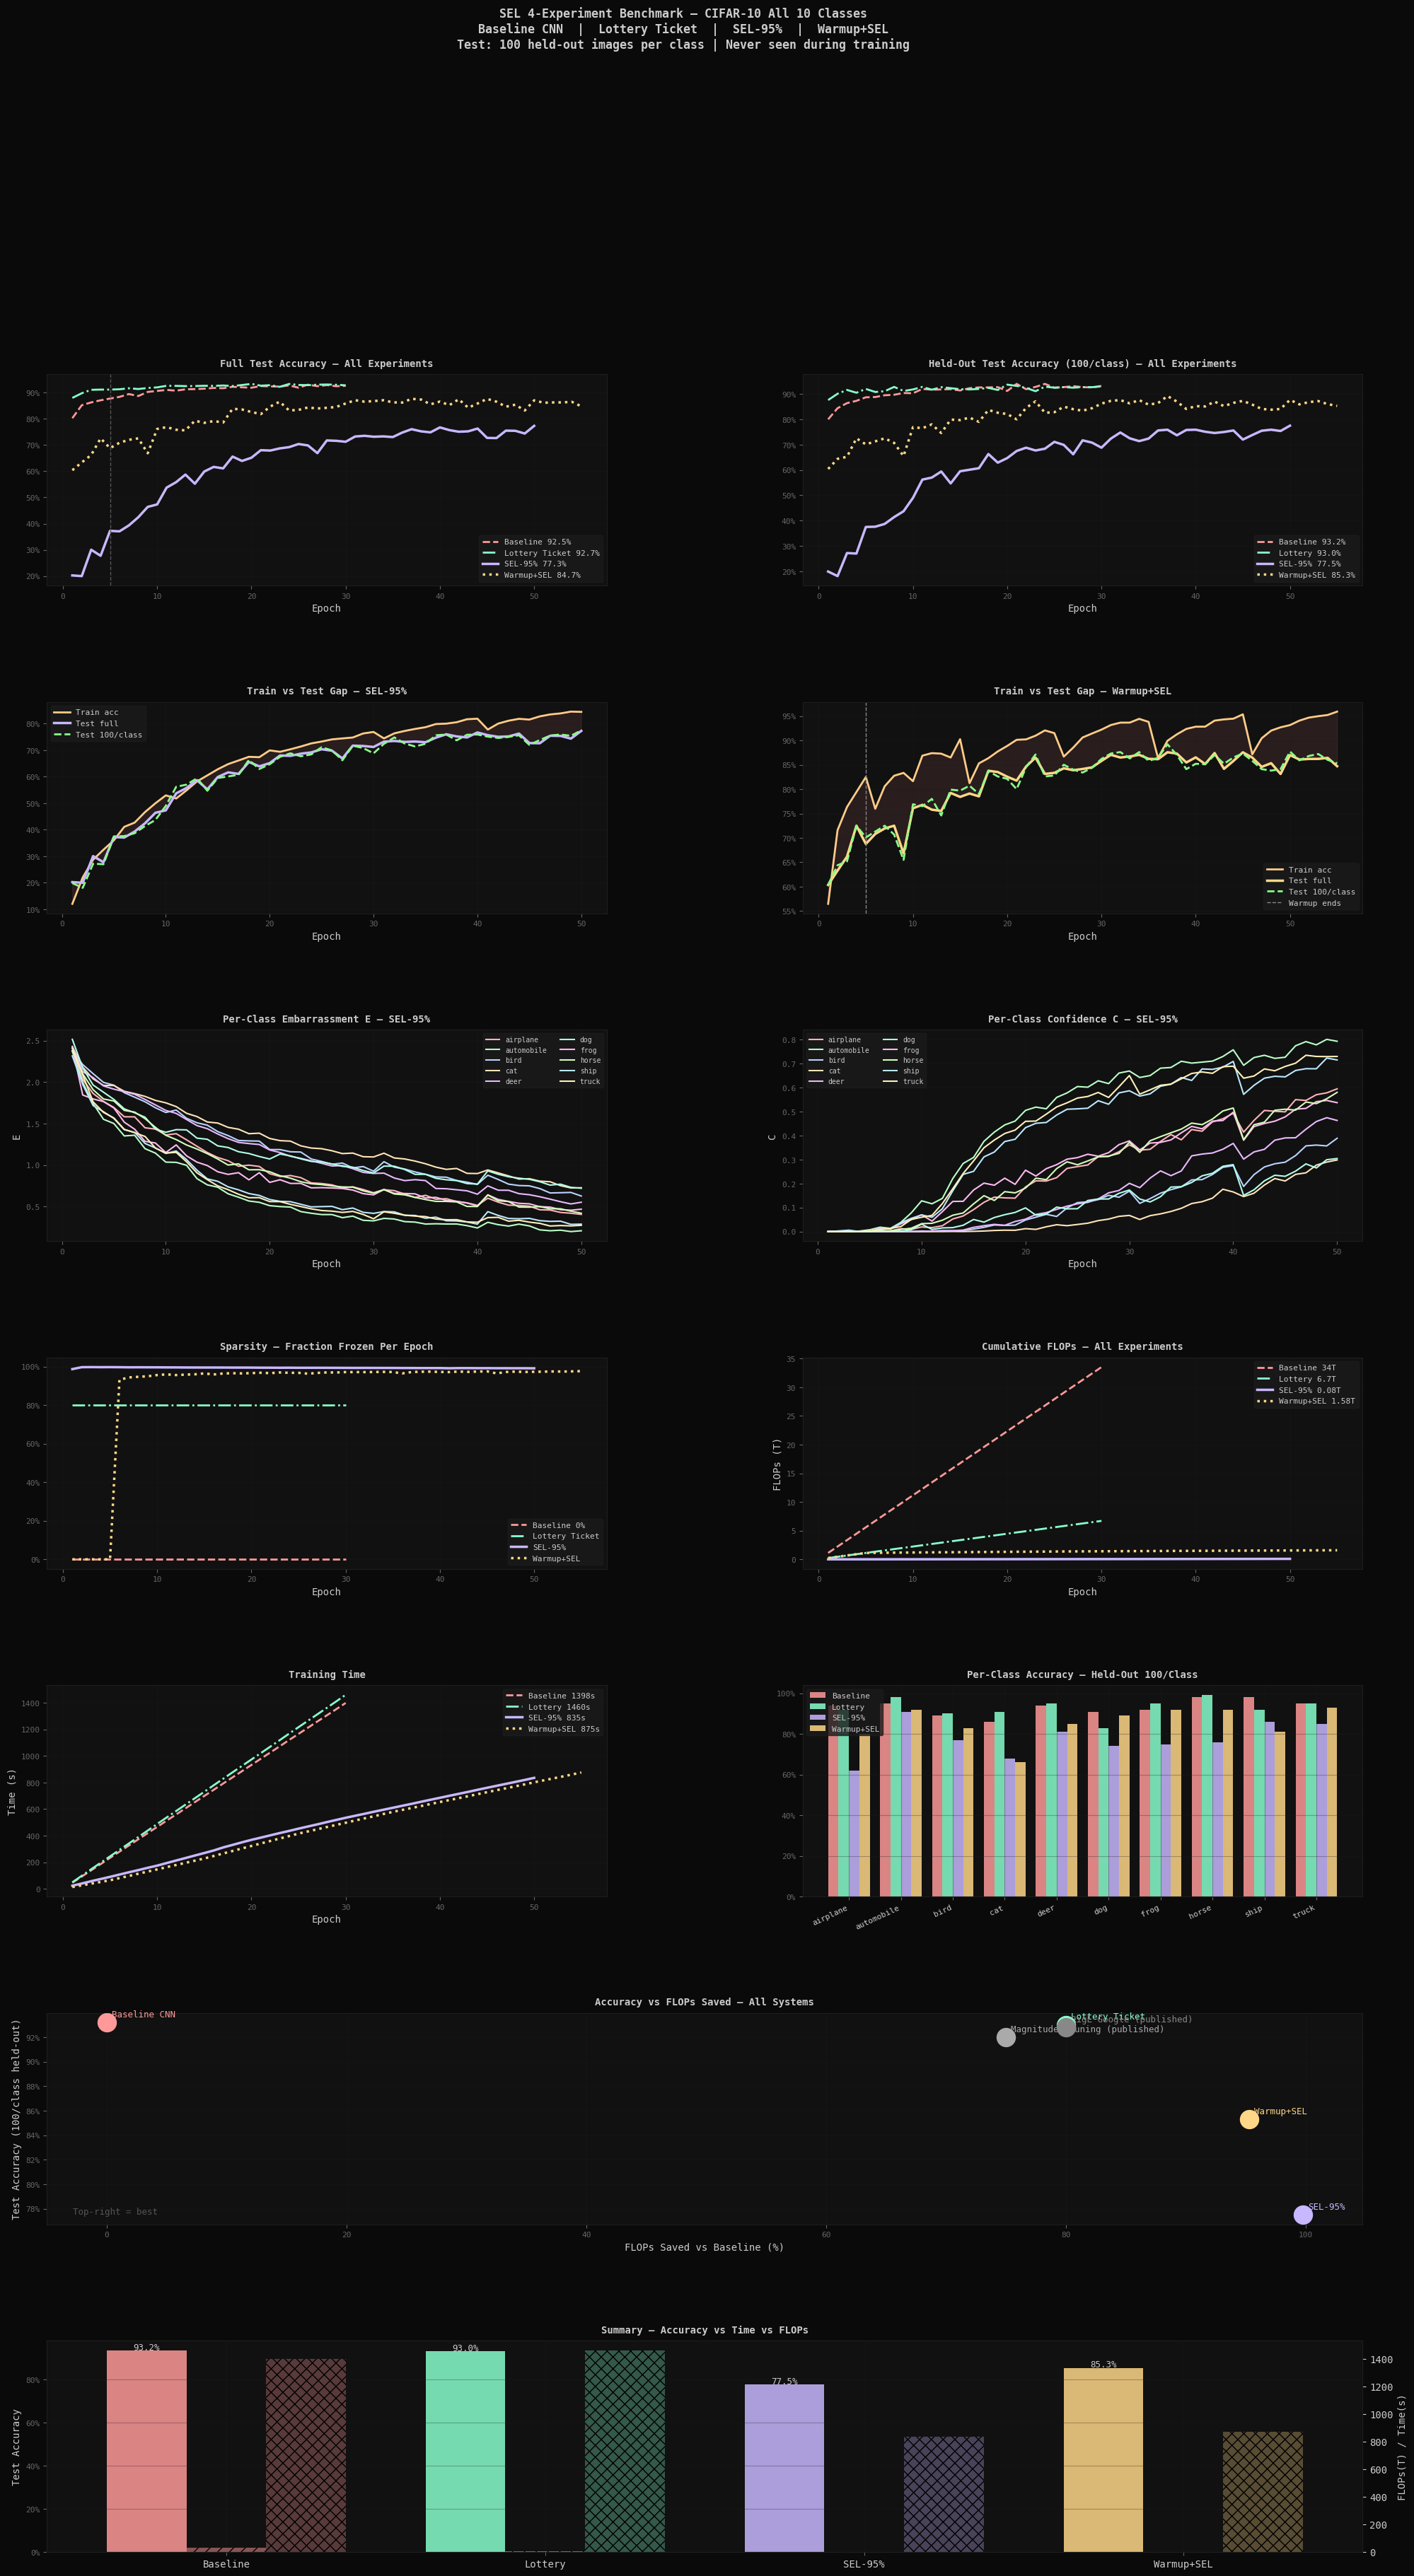

Saved benchmark_results.png


In [ ]:
# CELL 10 — All Graphs
BG='#0a0a0a'; CARD='#111111'; GRID='#1e1e1e'; TEXT='#cccccc'
C1='#ff9999'; C2='#88ffcc'; C3='#c8b8ff'; C4='#ffd788'  # exp colors
CLS_C=['#FFB3BA','#BAFFC9','#BAD4FF','#FFE4BA','#E8BAFF',
       '#B3FFE8','#FFBAF0','#D4FFBA','#BAE8FF','#FFF0BA']

plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':CARD,'axes.edgecolor':GRID,
    'axes.labelcolor':TEXT,'xtick.color':TEXT,'ytick.color':TEXT,
    'text.color':TEXT,'grid.color':GRID,'grid.alpha':0.3,
    'legend.facecolor':'#1a1a1a','legend.edgecolor':GRID,'font.family':'monospace'
})
def sx(ax,t):
    ax.set_facecolor(CARD); ax.set_title(t,color=TEXT,fontsize=10,fontweight='bold',pad=8)
    ax.tick_params(colors='#666',labelsize=8)
    for sp in ax.spines.values(): sp.set_color(GRID)
    ax.grid(True)
pct = plt.FuncFormatter(lambda y,_: f'{y:.0%}')

fig = plt.figure(figsize=(24,40))
gs  = gridspec.GridSpec(7,2,figure=fig,hspace=0.55,wspace=0.35)

# Align epochs for plotting — use test_full column
e1_ep=e1_df['epoch']; e2_ep=e2_df['epoch']; e3_ep=e3_df['epoch']; e4_ep=e4_df['epoch']

# 1 — Full test accuracy all 4
ax=fig.add_subplot(gs[0,0]); sx(ax,'Full Test Accuracy — All Experiments')
ax.plot(e1_ep,e1_df['test_full'],color=C1,lw=2,ls='--',label=f'Baseline {E1_FULL:.1%}')
ax.plot(e2_ep,e2_df['test_full'],color=C2,lw=2,ls='-.',label=f'Lottery Ticket {E2_FULL:.1%}')
ax.plot(e3_ep,e3_df['test_full'],color=C3,lw=2.5,label=f'SEL-95% {E3_FULL:.1%}')
ax.plot(e4_ep,e4_df['test_full'],color=C4,lw=2.5,ls=':',label=f'Warmup+SEL {E4_FULL:.1%}')
ax.axvline(WARMUP_EPOCHS,color='#555',lw=1,ls='--')
ax.set_xlabel('Epoch'); ax.yaxis.set_major_formatter(pct); ax.legend(fontsize=8)

# 2 — 100/class test accuracy all 4
ax=fig.add_subplot(gs[0,1]); sx(ax,'Held-Out Test Accuracy (100/class) — All Experiments')
ax.plot(e1_ep,e1_df['test_100'],color=C1,lw=2,ls='--',label=f'Baseline {E1_100:.1%}')
ax.plot(e2_ep,e2_df['test_100'],color=C2,lw=2,ls='-.',label=f'Lottery {E2_100:.1%}')
ax.plot(e3_ep,e3_df['test_100'],color=C3,lw=2.5,label=f'SEL-95% {E3_100:.1%}')
ax.plot(e4_ep,e4_df['test_100'],color=C4,lw=2.5,ls=':',label=f'Warmup+SEL {E4_100:.1%}')
ax.set_xlabel('Epoch'); ax.yaxis.set_major_formatter(pct); ax.legend(fontsize=8)

# 3 — Train vs Test gap (overfitting check)
ax=fig.add_subplot(gs[1,0]); sx(ax,'Train vs Test Gap — SEL-95%')
ax.plot(e3_ep,e3_df['train_acc'],color='#ffcc88',lw=2,label='Train acc')
ax.plot(e3_ep,e3_df['test_full'],color=C3,lw=2.5,label='Test full')
ax.plot(e3_ep,e3_df['test_100'], color='#88ff88',lw=2,ls='--',label='Test 100/class')
ax.fill_between(e3_ep,e3_df['train_acc'],e3_df['test_full'],alpha=0.1,color='#ff8888')
ax.set_xlabel('Epoch'); ax.yaxis.set_major_formatter(pct); ax.legend(fontsize=8)

# 4 — Train vs Test gap (warmup+SEL)
ax=fig.add_subplot(gs[1,1]); sx(ax,'Train vs Test Gap — Warmup+SEL')
ax.plot(e4_ep,e4_df['train_acc'],color='#ffcc88',lw=2,label='Train acc')
ax.plot(e4_ep,e4_df['test_full'],color=C4,lw=2.5,label='Test full')
ax.plot(e4_ep,e4_df['test_100'], color='#88ff88',lw=2,ls='--',label='Test 100/class')
ax.fill_between(e4_ep,e4_df['train_acc'],e4_df['test_full'],alpha=0.1,color='#ff8888')
ax.axvline(WARMUP_EPOCHS,color='#888',lw=1,ls='--',label='Warmup ends')
ax.set_xlabel('Epoch'); ax.yaxis.set_major_formatter(pct); ax.legend(fontsize=8)

# 5 — Per-class E (SEL-95)
ax=fig.add_subplot(gs[2,0]); sx(ax,'Per-Class Embarrassment E — SEL-95%')
for ci,cn in enumerate(CLASS_NAMES):
    if f'E_{cn}' in e3_df.columns:
        ax.plot(e3_ep,e3_df[f'E_{cn}'],color=CLS_C[ci],lw=1.5,label=cn)
ax.set_xlabel('Epoch'); ax.set_ylabel('E'); ax.legend(fontsize=7,ncol=2)

# 6 — Per-class C (SEL-95)
ax=fig.add_subplot(gs[2,1]); sx(ax,'Per-Class Confidence C — SEL-95%')
for ci,cn in enumerate(CLASS_NAMES):
    if f'C_{cn}' in e3_df.columns:
        ax.plot(e3_ep,e3_df[f'C_{cn}'],color=CLS_C[ci],lw=1.5,label=cn)
ax.set_xlabel('Epoch'); ax.set_ylabel('C'); ax.legend(fontsize=7,ncol=2)

# 7 — Sparsity over time
ax=fig.add_subplot(gs[3,0]); sx(ax,'Sparsity — Fraction Frozen Per Epoch')
ax.plot(e1_ep,e1_df['sparsity'],color=C1,lw=2,ls='--',label='Baseline 0%')
ax.plot(e2_ep,e2_df['sparsity'],color=C2,lw=2,ls='-.',label='Lottery Ticket')
ax.plot(e3_ep,e3_df['sparsity'],color=C3,lw=2.5,label='SEL-95%')
ax.plot(e4_ep,e4_df['sparsity'],color=C4,lw=2.5,ls=':',label='Warmup+SEL')
ax.set_xlabel('Epoch'); ax.yaxis.set_major_formatter(pct); ax.legend(fontsize=8)

# 8 — Cumulative FLOPs
ax=fig.add_subplot(gs[3,1]); sx(ax,'Cumulative FLOPs — All Experiments')
ax.plot(e1_ep,e1_df['flops_T'],color=C1,lw=2,ls='--',label=f'Baseline {e1_flops/1e12:.0f}T')
ax.plot(e2_ep,e2_df['flops_T'],color=C2,lw=2,ls='-.',label=f'Lottery {e2_flops/1e12:.1f}T')
ax.plot(e3_ep,e3_df['flops_T'],color=C3,lw=2.5,label=f'SEL-95% {e3_flops/1e12:.2f}T')
ax.plot(e4_ep,e4_df['flops_T'],color=C4,lw=2.5,ls=':',label=f'Warmup+SEL {e4_flops/1e12:.2f}T')
ax.set_xlabel('Epoch'); ax.set_ylabel('FLOPs (T)'); ax.legend(fontsize=8)

# 9 — Training time
ax=fig.add_subplot(gs[4,0]); sx(ax,'Training Time')
ax.plot(e1_ep,e1_df['time_s'],color=C1,lw=2,ls='--',label=f'Baseline {e1_elapsed:.0f}s')
ax.plot(e2_ep,e2_df['time_s'],color=C2,lw=2,ls='-.',label=f'Lottery {e2_elapsed:.0f}s')
ax.plot(e3_ep,e3_df['time_s'],color=C3,lw=2.5,label=f'SEL-95% {e3_elapsed:.0f}s')
ax.plot(e4_ep,e4_df['time_s'],color=C4,lw=2.5,ls=':',label=f'Warmup+SEL {e4_elapsed:.0f}s')
ax.set_xlabel('Epoch'); ax.set_ylabel('Time (s)'); ax.legend(fontsize=8)

# 10 — Per-class bar (100/class held-out)
ax=fig.add_subplot(gs[4,1]); sx(ax,'Per-Class Accuracy — Held-Out 100/Class')
x=np.arange(N_CLASSES); w=0.2
ax.bar(x-1.5*w, E1_PC, w, color=C1, alpha=0.85, label='Baseline')
ax.bar(x-0.5*w, E2_PC, w, color=C2, alpha=0.85, label='Lottery')
ax.bar(x+0.5*w, E3_PC, w, color=C3, alpha=0.85, label='SEL-95%')
ax.bar(x+1.5*w, E4_PC, w, color=C4, alpha=0.85, label='Warmup+SEL')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES,rotation=25,ha='right',color=TEXT,fontsize=8)
ax.yaxis.set_major_formatter(pct); ax.legend(fontsize=8)

# 11 — Accuracy vs FLOPs scatter
ax=fig.add_subplot(gs[5,:]); sx(ax,'Accuracy vs FLOPs Saved — All Systems')
baseline_f = e1_flops/1e12
systems = [
    ('Baseline CNN',    E1_100, 0.0,                        C1),
    ('Lottery Ticket',  E2_100, (1-e2_flops/1e12/baseline_f)*100, C2),
    ('SEL-95%',         E3_100, (1-e3_flops/1e12/baseline_f)*100, C3),
    ('Warmup+SEL',      E4_100, (1-e4_flops/1e12/baseline_f)*100, C4),
    ('Magnitude Pruning (published)', 0.920, 75.0, '#aaaaaa'),
    ('RigL Google (published)',       0.928, 80.0, '#888888'),
]
for sname,acc,saved,sc in systems:
    ax.scatter(saved,acc,color=sc,s=350,zorder=5)
    ax.annotate(sname,(saved,acc),xytext=(5,6),textcoords='offset points',fontsize=9,color=sc)
ax.set_xlabel('FLOPs Saved vs Baseline (%)')
ax.set_ylabel('Test Accuracy (100/class held-out)')
ax.yaxis.set_major_formatter(pct)
ax.text(0.02,0.05,'Top-right = best',transform=ax.transAxes,color='#555',fontsize=9)

# 12 — Summary bar
ax=fig.add_subplot(gs[6,:]); sx(ax,'Summary — Accuracy vs Time vs FLOPs')
exp_labels=['Baseline','Lottery','SEL-95%','Warmup+SEL']
acc_vals  =[E1_100,E2_100,E3_100,E4_100]
flop_vals =[e1_flops/1e12,e2_flops/1e12,e3_flops/1e12,e4_flops/1e12]
time_vals =[e1_elapsed,e2_elapsed,e3_elapsed,e4_elapsed]
exp_colors=[C1,C2,C3,C4]
x=np.arange(4); w=0.25
ax2=ax.twinx()
ax.bar(x-w,   acc_vals,  w, color=exp_colors, alpha=0.85, label='Accuracy (left)')
ax2.bar(x,    flop_vals, w, color=exp_colors, alpha=0.5,  hatch='//')
ax2.bar(x+w,  time_vals, w, color=exp_colors, alpha=0.3,  hatch='xx')
ax.set_xticks(x); ax.set_xticklabels(exp_labels,color=TEXT,fontsize=10)
ax.set_ylabel('Test Accuracy',color=TEXT)
ax2.set_ylabel('FLOPs(T) / Time(s)',color=TEXT)
ax.yaxis.set_major_formatter(pct)
for xi,v in enumerate(acc_vals):
    ax.text(xi-w, v+0.003, f'{v:.1%}', ha='center', fontsize=9, color=TEXT)

fig.suptitle(
    'SEL 4-Experiment Benchmark — CIFAR-10 All 10 Classes\n'
    'Baseline CNN  |  Lottery Ticket  |  SEL-95%  |  Warmup+SEL\n'
    'Test: 100 held-out images per class | Never seen during training',
    fontsize=12, fontweight='bold', y=1.01, color=TEXT
)
plt.savefig('/content/benchmark_results.png', dpi=130,
            bbox_inches='tight', facecolor=BG, edgecolor='none')
plt.show()
print('Saved benchmark_results.png')

In [4]:
# CELL 11 — Final Summary + Download
from google.colab import files

bf = e1_flops/1e12
print('='*72)
print('  4-EXPERIMENT BENCHMARK — HELD-OUT TEST (100 IMAGES PER CLASS)')
print('='*72)
print(f'  {"System":<18} {"Full Test":>10} {"100/class":>10} {"FLOPs":>9} {"Time":>8} {"FLOPs saved":>12}')
print('-'*72)
for label,full,t100,fl,tm in [
    ('Baseline CNN',   E1_FULL, E1_100, e1_flops/1e12, e1_elapsed),
    ('Lottery Ticket', E2_FULL, E2_100, e2_flops/1e12, e2_elapsed),
    ('SEL-95%',        E3_FULL, E3_100, e3_flops/1e12, e3_elapsed),
    ('Warmup+SEL',     E4_FULL, E4_100, e4_flops/1e12, e4_elapsed),
]:
    saved = (1-fl/bf)*100
    print(f'  {label:<18} {full:>9.1%} {t100:>9.1%} {fl:>8.2f}T {tm:>7.0f}s {saved:>11.0f}%')
print('='*72)

print('\nPer-class accuracy on 100 held-out images:')
print(f'  {"Class":<12} {"Baseline":>9} {"Lottery":>9} {"SEL-95%":>9} {"Warm+SEL":>10}')
print('-'*52)
for ci,cn in enumerate(CLASS_NAMES):
    print(f'  {cn:<12} {E1_PC[ci]:>8.0%} {E2_PC[ci]:>8.0%} {E3_PC[ci]:>8.0%} {E4_PC[ci]:>9.0%}')

e1_df.to_csv('/content/hist_baseline.csv', index=False)
e2_df.to_csv('/content/hist_lottery.csv',  index=False)
e3_df.to_csv('/content/hist_sel95.csv',    index=False)
e4_df.to_csv('/content/hist_warmup.csv',   index=False)

for f in ['/content/benchmark_results.png',
          '/content/hist_baseline.csv',
          '/content/hist_lottery.csv',
          '/content/hist_sel95.csv',
          '/content/hist_warmup.csv']:
    files.download(f)
print('\nAll downloaded')

NameError: name 'e1_flops' is not defined